# FAILSAFE — Exploratory Data Analysis
### UCI Student Performance Dataset (Math + Portuguese)

## 1. Imports and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# just so plots look decent
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

mat = pd.read_csv("./data/student-mat.csv", sep=";")
por = pd.read_csv("./data/student-por.csv", sep=";")

print("Math dataset shape     :", mat.shape)
print("Portuguese dataset shape:", por.shape)

Math dataset shape     : (395, 33)
Portuguese dataset shape: (649, 33)


## 2. Quick Look at the Data

In [2]:
print("=== Math Dataset - First 5 rows ===")
mat.head()

=== Math Dataset - First 5 rows ===


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [3]:
print("=== Math Dataset - Column Info ===")
mat.info()

=== Math Dataset - Column Info ===
<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher  

In [4]:
print("=== Missing Values (Math) ===")
print(mat.isnull().sum().sum(), "missing values")

print("\n=== Missing Values (Portuguese) ===")
print(por.isnull().sum().sum(), "missing values")

print("\nDataset is clean — no missing values in either file.")

=== Missing Values (Math) ===
0 missing values

=== Missing Values (Portuguese) ===
0 missing values

Dataset is clean — no missing values in either file.


In [5]:
print("=== Basic Stats (Math) ===")
mat.describe().round(2)

=== Basic Stats (Math) ===


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00
mean,16.70,2.75,2.52,1.45,2.04,0.33,3.94,3.24,3.11,1.48,2.29,3.55,5.71,10.91,10.71,10.42
std,1.28,1.09,1.09,0.70,0.84,0.74,0.90,1.00,1.11,0.89,1.29,1.39,8.00,3.32,3.76,4.58
min,15.00,0.00,0.00,1.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,3.00,0.00,0.00
25%,16.00,2.00,2.00,1.00,1.00,0.00,4.00,3.00,2.00,1.00,1.00,3.00,0.00,8.00,9.00,8.00
50%,17.00,3.00,2.00,1.00,2.00,0.00,4.00,3.00,3.00,1.00,2.00,4.00,4.00,11.00,11.00,11.00
75%,18.00,4.00,3.00,2.00,2.00,0.00,5.00,4.00,4.00,2.00,3.00,5.00,8.00,13.00,13.00,14.00
max,22.00,4.00,4.00,4.00,4.00,3.00,5.00,5.00,5.00,5.00,5.00,5.00,75.00,19.00,19.00,20.00


## 3. Target Variable — G3 (Final Grade)

We define **at-risk** as G3 < 10.

In [6]:
# create the at_risk label
mat["at_risk"] = (mat["G3"] < 10).astype(int)
por["at_risk"] = (por["G3"] < 10).astype(int)

print("=== Math ===")
print(f"At-risk students  : {mat['at_risk'].sum()} ({mat['at_risk'].mean()*100:.1f}%)")
print(f"Safe students     : {(mat['at_risk']==0).sum()} ({(mat['at_risk']==0).mean()*100:.1f}%)")

print("\n=== Portuguese ===")
print(f"At-risk students  : {por['at_risk'].sum()} ({por['at_risk'].mean()*100:.1f}%)")
print(f"Safe students     : {(por['at_risk']==0).sum()} ({(por['at_risk']==0).mean()*100:.1f}%)")

=== Math ===
At-risk students  : 130 (32.9%)
Safe students     : 265 (67.1%)

=== Portuguese ===
At-risk students  : 100 (15.4%)
Safe students     : 549 (84.6%)


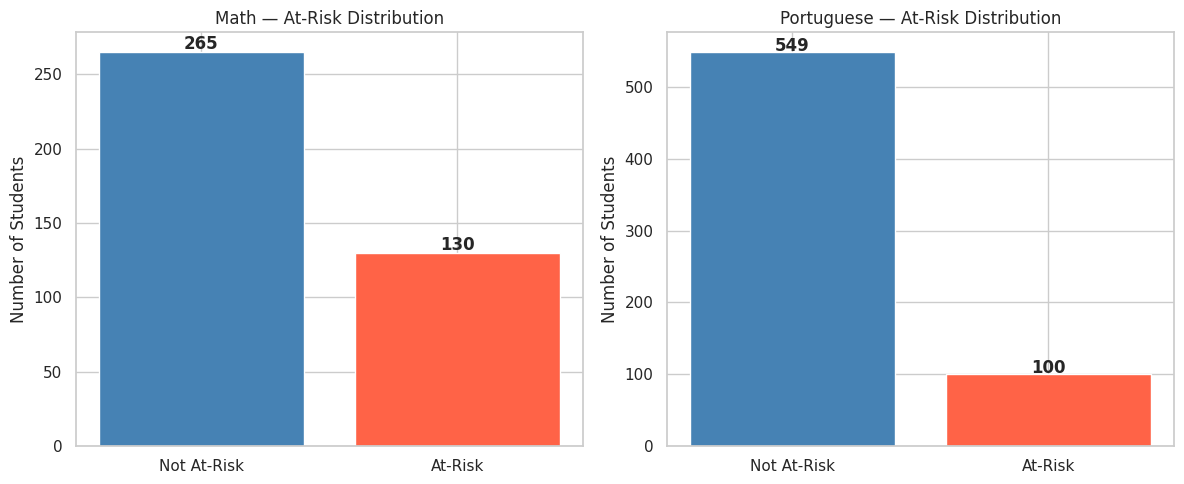

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, df, title in zip(axes, [mat, por], ["Math", "Portuguese"]):
    counts = df["at_risk"].value_counts()
    ax.bar(["Not At-Risk", "At-Risk"], counts.values, color=["steelblue", "tomato"], edgecolor="white")
    ax.set_title(f"{title} — At-Risk Distribution")
    ax.set_ylabel("Number of Students")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 2, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

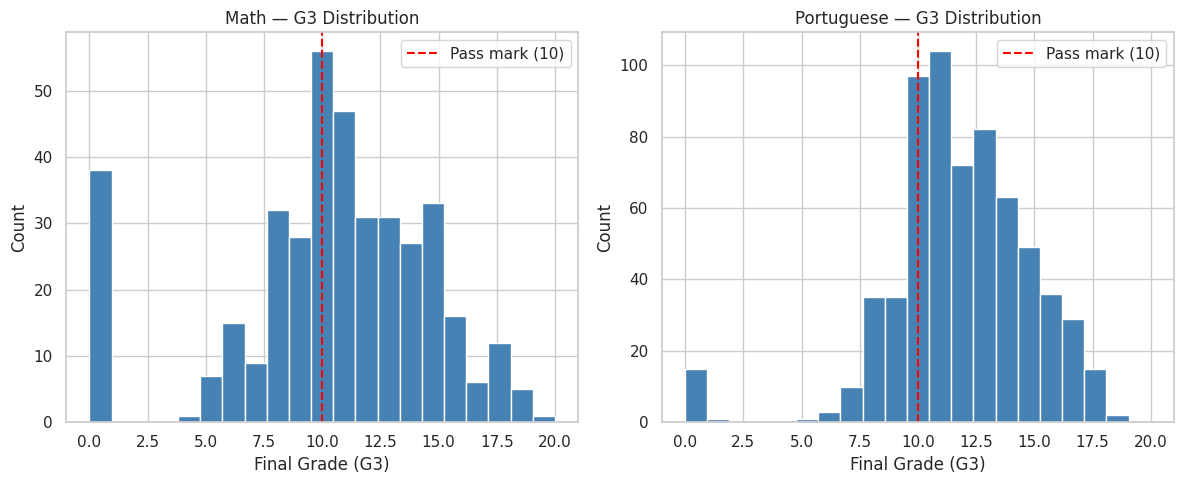

Math   — G3 mean: 10.42 | median: 11.0
Port.  — G3 mean: 11.91 | median: 12.0

Note: G3 = 0 students are likely dropouts or absent from final exam
  Math: 38 students with G3=0
  Port: 15 students with G3=0


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, df, title in zip(axes, [mat, por], ["Math", "Portuguese"]):
    ax.hist(df["G3"], bins=21, range=(0, 20), color="steelblue", edgecolor="white")
    ax.axvline(x=10, color="red", linestyle="--", linewidth=1.5, label="Pass mark (10)")
    ax.set_title(f"{title} — G3 Distribution")
    ax.set_xlabel("Final Grade (G3)")
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.show()

print("Math   — G3 mean:", round(mat["G3"].mean(), 2), "| median:", mat["G3"].median())
print("Port.  — G3 mean:", round(por["G3"].mean(), 2), "| median:", por["G3"].median())
print("\nNote: G3 = 0 students are likely dropouts or absent from final exam")
print(f"  Math: {(mat['G3']==0).sum()} students with G3=0")
print(f"  Port: {(por['G3']==0).sum()} students with G3=0")

## 4. Grade Progression — G1 → G2 → G3

Do students improve or decline over the semester?

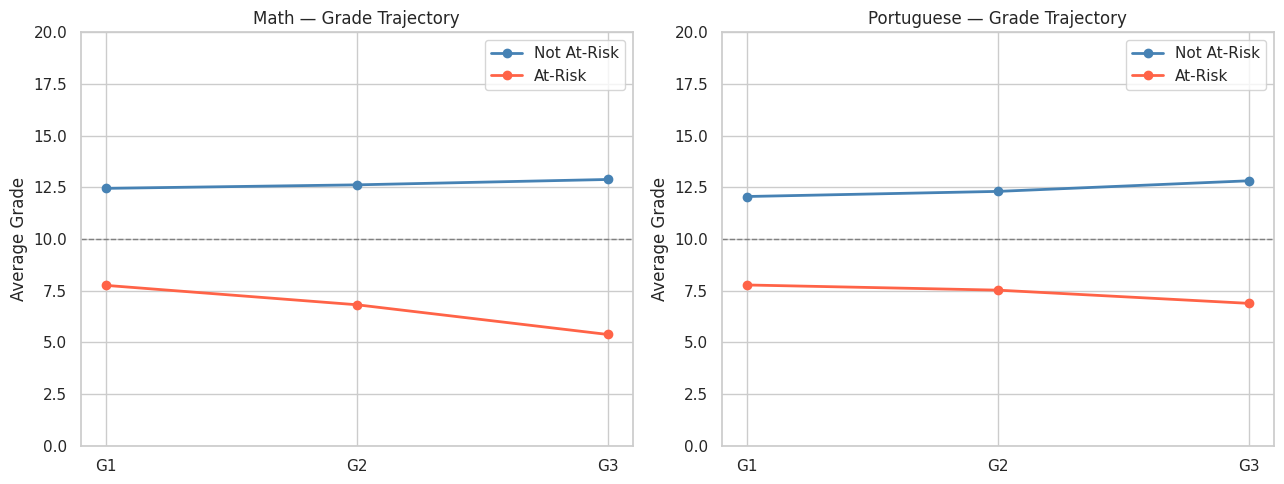

=== Math ===
At-Risk  — G1: 7.76 | G2: 6.82 | G3: 5.38
Not Risk — G1: 12.45 | G2: 12.62 | G3: 12.88


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, df, title in zip(axes, [mat, por], ["Math", "Portuguese"]):
    at_risk_grp  = df[df["at_risk"] == 1][["G1","G2","G3"]].mean()
    safe_grp     = df[df["at_risk"] == 0][["G1","G2","G3"]].mean()

    ax.plot(["G1","G2","G3"], safe_grp.values,  marker="o", label="Not At-Risk", color="steelblue", linewidth=2)
    ax.plot(["G1","G2","G3"], at_risk_grp.values, marker="o", label="At-Risk",  color="tomato",    linewidth=2)
    ax.set_title(f"{title} — Grade Trajectory")
    ax.set_ylabel("Average Grade")
    ax.set_ylim(0, 20)
    ax.legend()
    ax.axhline(y=10, color="gray", linestyle="--", linewidth=1, label="Pass mark")

plt.tight_layout()
plt.show()

print("=== Math ===")
print("At-Risk  — G1:", round(mat[mat.at_risk==1]["G1"].mean(),2),
      "| G2:", round(mat[mat.at_risk==1]["G2"].mean(),2),
      "| G3:", round(mat[mat.at_risk==1]["G3"].mean(),2))
print("Not Risk — G1:", round(mat[mat.at_risk==0]["G1"].mean(),2),
      "| G2:", round(mat[mat.at_risk==0]["G2"].mean(),2),
      "| G3:", round(mat[mat.at_risk==0]["G3"].mean(),2))

## 5. Correlation Heatmap — Numeric Features

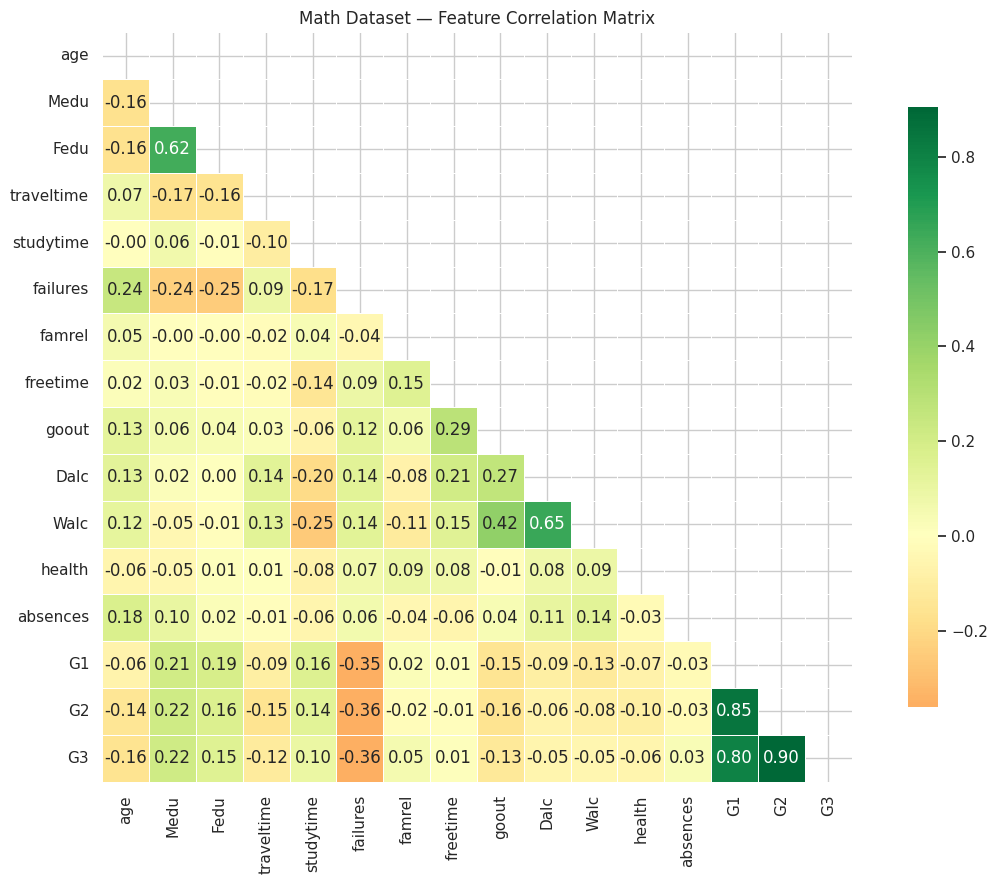


Top correlations with G3:
G2            0.905
G1            0.801
failures     -0.360
Medu          0.217
age          -0.162
Fedu          0.152
goout        -0.133
traveltime   -0.117
studytime     0.098
health       -0.061
Dalc         -0.055
Walc         -0.052
famrel        0.051
absences      0.034
freetime      0.011


In [10]:
num_cols = ["age","Medu","Fedu","traveltime","studytime","failures",
            "famrel","freetime","goout","Dalc","Walc","health","absences","G1","G2","G3"]

corr = mat[num_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Math Dataset — Feature Correlation Matrix")
plt.tight_layout()
plt.show()

print("\nTop correlations with G3:")
g3_corr = corr["G3"].drop("G3").sort_values(key=abs, ascending=False)
print(g3_corr.round(3).to_string())

## 6. Key Features vs At-Risk

Comparing mean values for at-risk vs non-at-risk students.

In [11]:
compare_cols = ["absences","studytime","failures","Dalc","Walc","famrel","G1","G2"]

result = mat.groupby("at_risk")[compare_cols].mean().T
result.columns = ["Not At-Risk", "At-Risk"]
result["Difference"] = (result["At-Risk"] - result["Not At-Risk"]).round(2)
result = result.round(2)

print("=== Math — Mean Feature Values by Risk Group ===")
print(result.to_string())

=== Math — Mean Feature Values by Risk Group ===
           Not At-Risk  At-Risk  Difference
absences          5.19     6.76        1.57
studytime         2.08     1.95       -0.13
failures          0.16     0.69        0.53
Dalc              1.45     1.55        0.11
Walc              2.26     2.35        0.08
famrel            3.97     3.88       -0.09
G1               12.45     7.76       -4.69
G2               12.62     6.82       -5.80


/tmp/ipykernel_63280/2388743833.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["Not At-Risk", "At-Risk"], patch_artist=True,
/tmp/ipykernel_63280/2388743833.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["Not At-Risk", "At-Risk"], patch_artist=True,
/tmp/ipykernel_63280/2388743833.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["Not At-Risk", "At-Risk"], patch_artist=True,
/tmp/ipykernel_63280/2388743833.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; sup

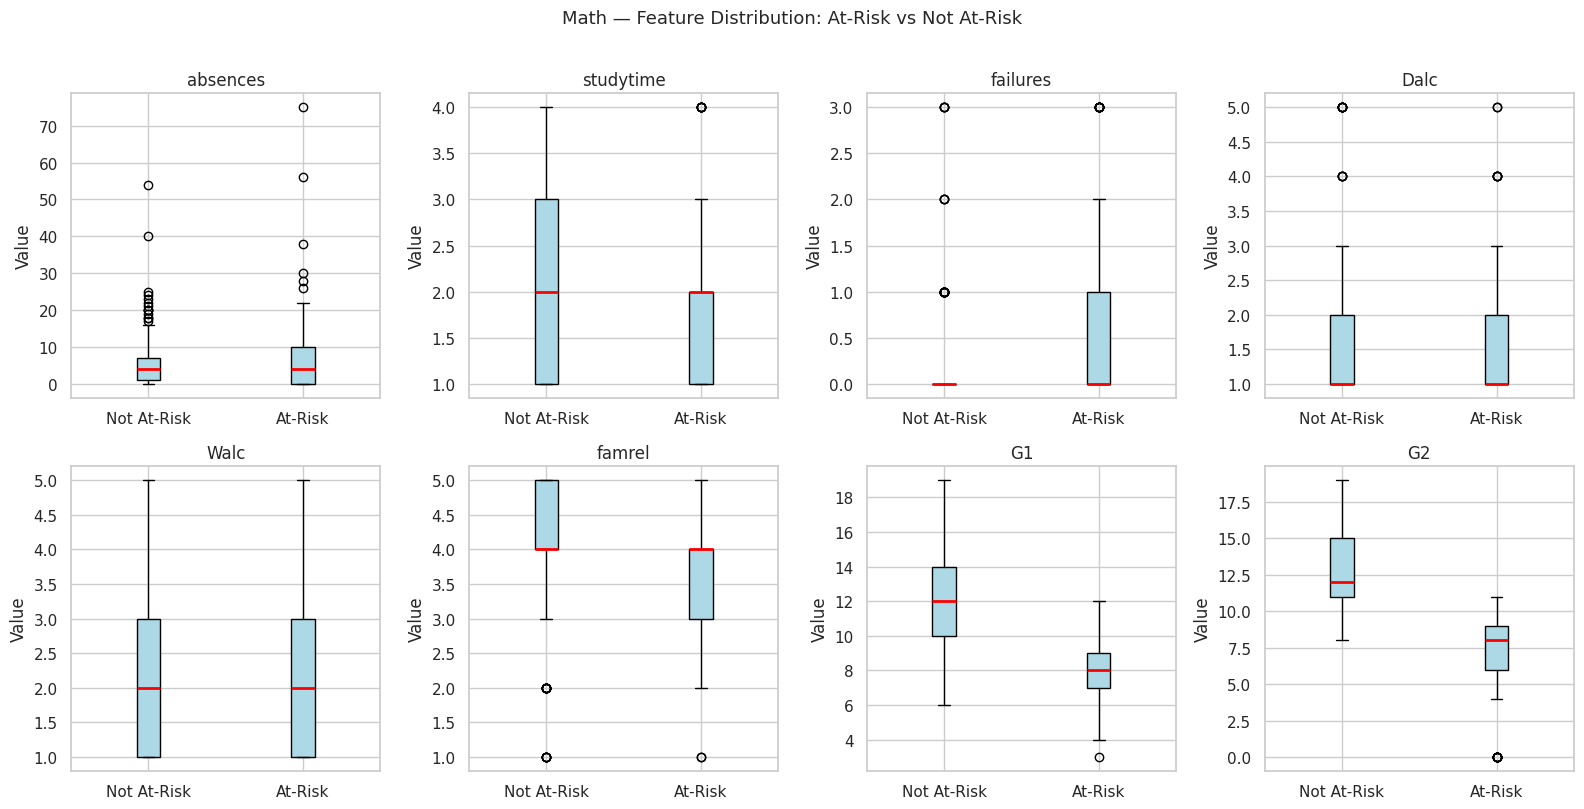

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

compare_cols = ["absences","studytime","failures","Dalc","Walc","famrel","G1","G2"]

for i, col in enumerate(compare_cols):
    ax = axes[i]
    data = [mat[mat["at_risk"]==0][col], mat[mat["at_risk"]==1][col]]
    ax.boxplot(data, labels=["Not At-Risk", "At-Risk"], patch_artist=True,
               boxprops=dict(facecolor="lightblue"),
               medianprops=dict(color="red", linewidth=2))
    ax.set_title(col)
    ax.set_ylabel("Value")

plt.suptitle("Math — Feature Distribution: At-Risk vs Not At-Risk", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 7. Past Failures vs At-Risk Rate

One of the strongest predictors.

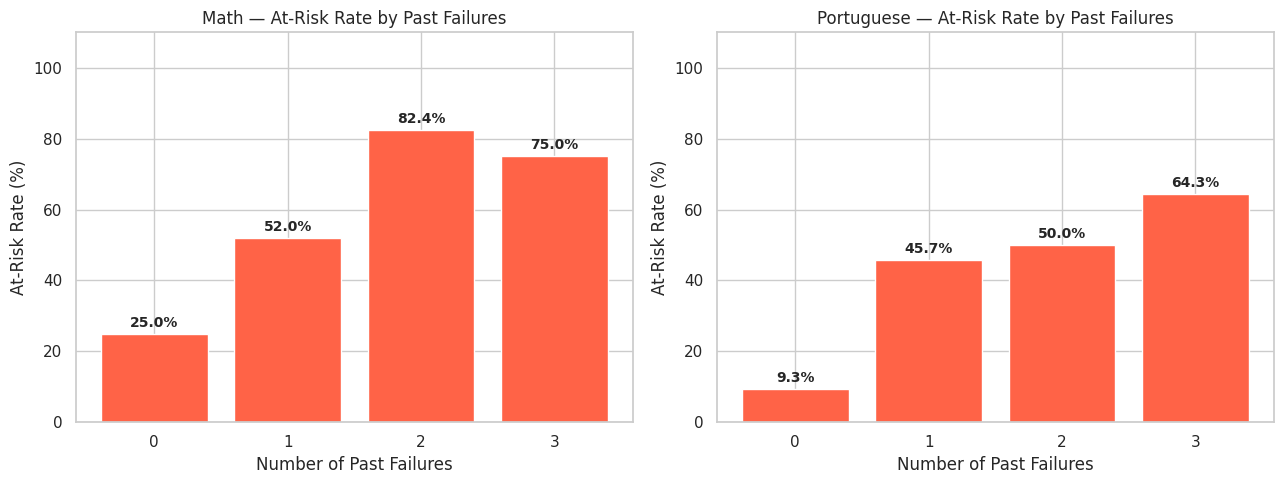

=== Math — At-Risk % by Past Failures ===
          Not At-Risk  At-Risk  At-Risk %
failures                                 
0                 234       78       25.0
1                  24       26       52.0
2                   3       14       82.4
3                   4       12       75.0


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, df, title in zip(axes, [mat, por], ["Math", "Portuguese"]):
    ct = pd.crosstab(df["failures"], df["at_risk"])
    ct.columns = ["Not At-Risk", "At-Risk"]
    ct["At-Risk %"] = (ct["At-Risk"] / ct.sum(axis=1) * 100).round(1)

    bars = ax.bar(ct.index.astype(str), ct["At-Risk %"], color="tomato", edgecolor="white")
    ax.set_title(f"{title} — At-Risk Rate by Past Failures")
    ax.set_xlabel("Number of Past Failures")
    ax.set_ylabel("At-Risk Rate (%)")
    ax.set_ylim(0, 110)
    for bar, val in zip(bars, ct["At-Risk %"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f"{val}%", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

print("=== Math — At-Risk % by Past Failures ===")
ct = pd.crosstab(mat["failures"], mat["at_risk"])
ct.columns = ["Not At-Risk", "At-Risk"]
ct["At-Risk %"] = (ct["At-Risk"] / ct.sum(axis=1) * 100).round(1)
print(ct.to_string())

## 8. Alcohol Consumption vs At-Risk

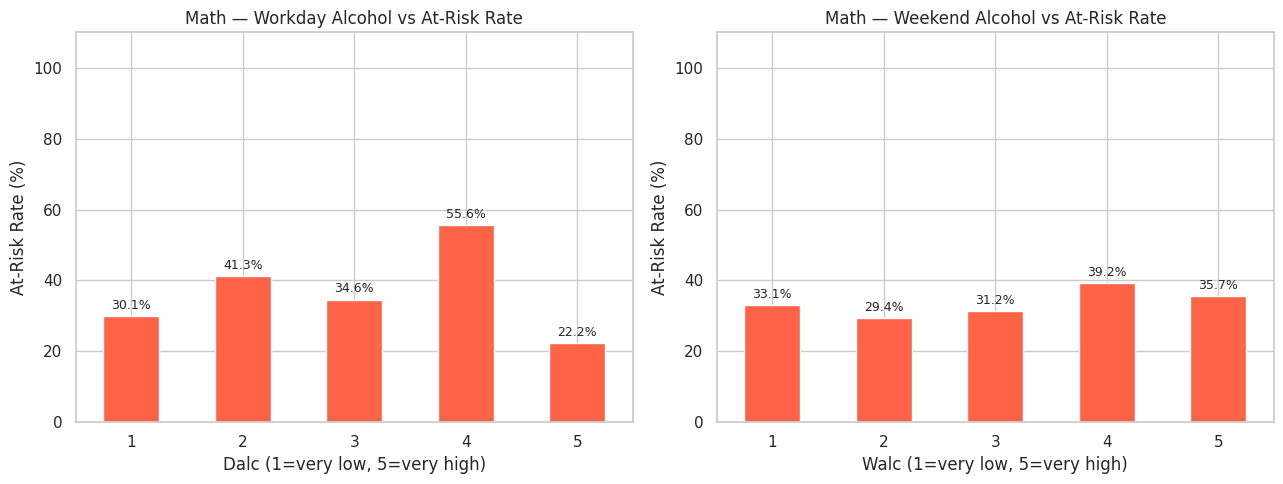

Dalc (workday alcohol) at-risk rates:
      Not At-Risk %  At-Risk %
Dalc                          
1              69.9       30.1
2              58.7       41.3
3              65.4       34.6
4              44.4       55.6
5              77.8       22.2


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, label in zip(axes, ["Dalc","Walc"], ["Workday Alcohol","Weekend Alcohol"]):
    ct = pd.crosstab(mat[col], mat["at_risk"], normalize="index") * 100
    ct.columns = ["Not At-Risk %", "At-Risk %"]
    ct["At-Risk %"].plot(kind="bar", ax=ax, color="tomato", edgecolor="white", rot=0)
    ax.set_title(f"Math — {label} vs At-Risk Rate")
    ax.set_xlabel(f"{col} (1=very low, 5=very high)")
    ax.set_ylabel("At-Risk Rate (%)")
    ax.set_ylim(0, 110)
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.1f}%",
                    (p.get_x() + p.get_width()/2, p.get_height() + 2),
                    ha="center", fontsize=9)

plt.tight_layout()
plt.show()

print("Dalc (workday alcohol) at-risk rates:")
ct = pd.crosstab(mat["Dalc"], mat["at_risk"], normalize="index") * 100
ct.columns = ["Not At-Risk %", "At-Risk %"]
print(ct.round(1).to_string())

## 9. Absences vs At-Risk

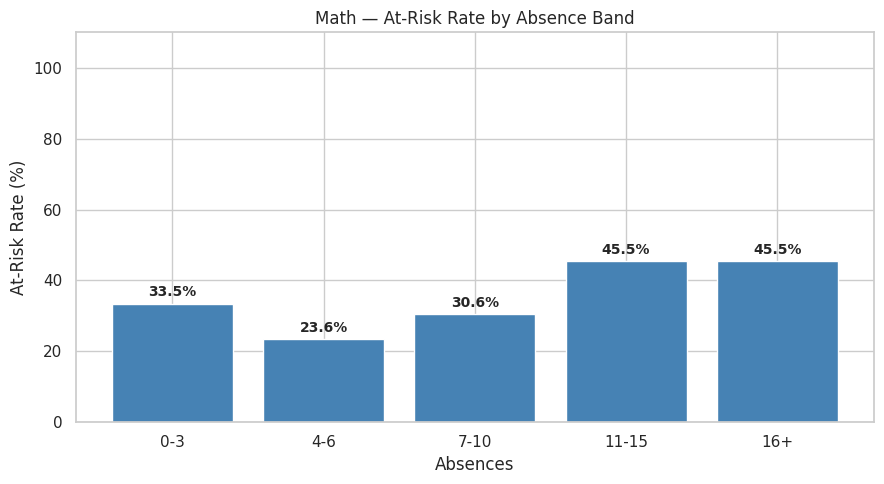

          Not At-Risk  At-Risk  At-Risk %
abs_band                                 
0-3               127       64       33.5
4-6                68       21       23.6
7-10               34       15       30.6
11-15              18       15       45.5
16+                18       15       45.5


In [15]:
bins  = [0, 3, 6, 10, 15, 94]
labels = ["0-3","4-6","7-10","11-15","16+"]
mat["abs_band"] = pd.cut(mat["absences"], bins=bins, labels=labels, include_lowest=True)

ct = pd.crosstab(mat["abs_band"], mat["at_risk"])
ct.columns = ["Not At-Risk", "At-Risk"]
ct["At-Risk %"] = (ct["At-Risk"] / ct.sum(axis=1) * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(ct.index.astype(str), ct["At-Risk %"], color="steelblue", edgecolor="white")
ax.set_title("Math — At-Risk Rate by Absence Band")
ax.set_xlabel("Absences")
ax.set_ylabel("At-Risk Rate (%)")
ax.set_ylim(0, 110)
for bar, val in zip(bars, ct["At-Risk %"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f"{val}%", ha="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()

print(ct.to_string())

## 10. Study Time vs At-Risk

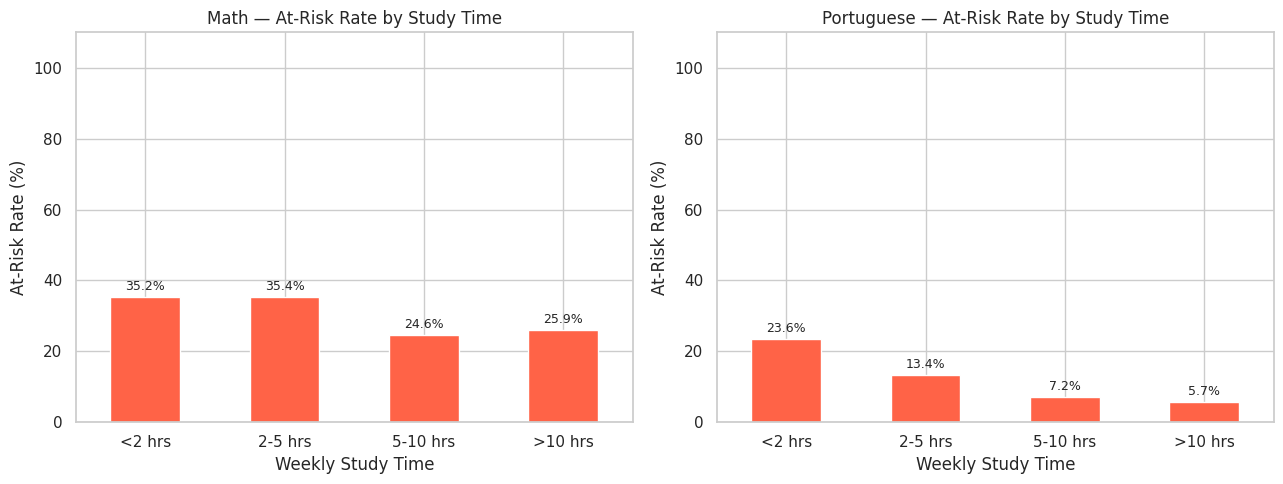

In [16]:
study_labels = {1: "<2 hrs", 2: "2-5 hrs", 3: "5-10 hrs", 4: ">10 hrs"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, df, title in zip(axes, [mat, por], ["Math", "Portuguese"]):
    ct = pd.crosstab(df["studytime"], df["at_risk"], normalize="index") * 100
    ct.columns = ["Not At-Risk %", "At-Risk %"]
    ct.index = [study_labels.get(i, str(i)) for i in ct.index]
    ct["At-Risk %"].plot(kind="bar", ax=ax, color="tomato", edgecolor="white", rot=0)
    ax.set_title(f"{title} — At-Risk Rate by Study Time")
    ax.set_xlabel("Weekly Study Time")
    ax.set_ylabel("At-Risk Rate (%)")
    ax.set_ylim(0, 110)
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.1f}%",
                    (p.get_x() + p.get_width()/2, p.get_height() + 2),
                    ha="center", fontsize=9)

plt.tight_layout()
plt.show()

## 11. Parent Education vs G3

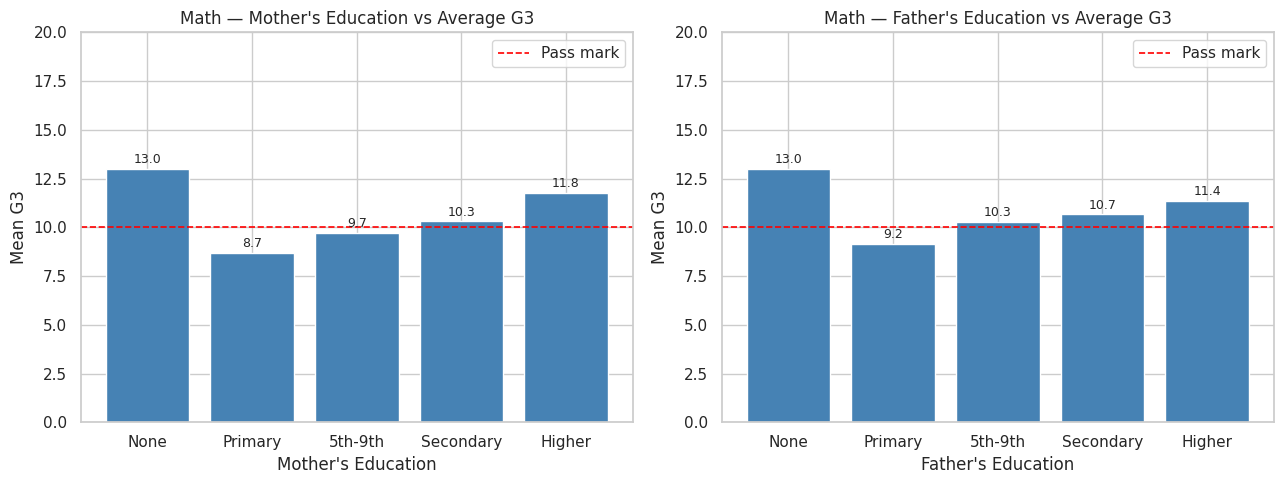

Mean G3 by Mother's Education (Math):
Medu
0    13.00
1     8.68
2     9.73
3    10.30
4    11.76


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
edu_labels = {0:"None", 1:"Primary", 2:"5th-9th", 3:"Secondary", 4:"Higher"}

for ax, col, label in zip(axes, ["Medu","Fedu"], ["Mother's Education","Father's Education"]):
    means = mat.groupby(col)["G3"].mean()
    means.index = [edu_labels.get(i, str(i)) for i in means.index]
    ax.bar(means.index, means.values, color="steelblue", edgecolor="white")
    ax.set_title(f"Math — {label} vs Average G3")
    ax.set_xlabel(label)
    ax.set_ylabel("Mean G3")
    ax.set_ylim(0, 20)
    ax.axhline(y=10, color="red", linestyle="--", linewidth=1.2, label="Pass mark")
    ax.legend()
    for i, v in enumerate(means.values):
        ax.text(i, v + 0.3, f"{v:.1f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

print("Mean G3 by Mother's Education (Math):")
print(mat.groupby("Medu")["G3"].mean().round(2).to_string())

## 12. At-Risk by Demographics (Sex, School, Address)

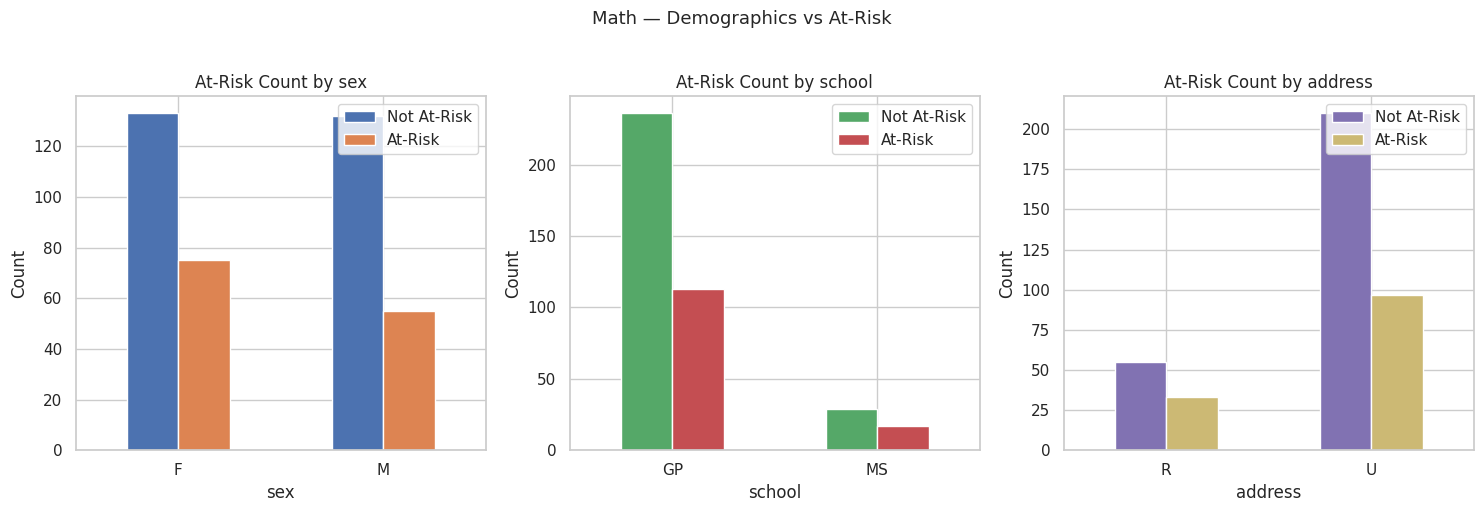


sex:
     Not At-Risk  At-Risk  At-Risk %
sex                                 
F            133       75       36.1
M            132       55       29.4

school:
        Not At-Risk  At-Risk  At-Risk %
school                                 
GP              236      113       32.4
MS               29       17       37.0

address:
         Not At-Risk  At-Risk  At-Risk %
address                                 
R                 55       33       37.5
U                210       97       31.6


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
demo_cols = ["sex","school","address"]
colors = [["#4C72B0","#DD8452"], ["#55A868","#C44E52"], ["#8172B2","#CCB974"]]

for ax, col, color in zip(axes, demo_cols, colors):
    ct = pd.crosstab(mat[col], mat["at_risk"])
    ct.columns = ["Not At-Risk", "At-Risk"]
    ct.plot(kind="bar", ax=ax, color=color, edgecolor="white", rot=0)
    ax.set_title(f"At-Risk Count by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.legend(loc="upper right")

plt.suptitle("Math — Demographics vs At-Risk", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

for col in ["sex","school","address"]:
    ct = pd.crosstab(mat[col], mat["at_risk"])
    ct.columns = ["Not At-Risk", "At-Risk"]
    ct["At-Risk %"] = (ct["At-Risk"] / ct.sum(axis=1) * 100).round(1)
    print(f"\n{col}:")
    print(ct.to_string())

## 13. Family Relationship Quality vs At-Risk

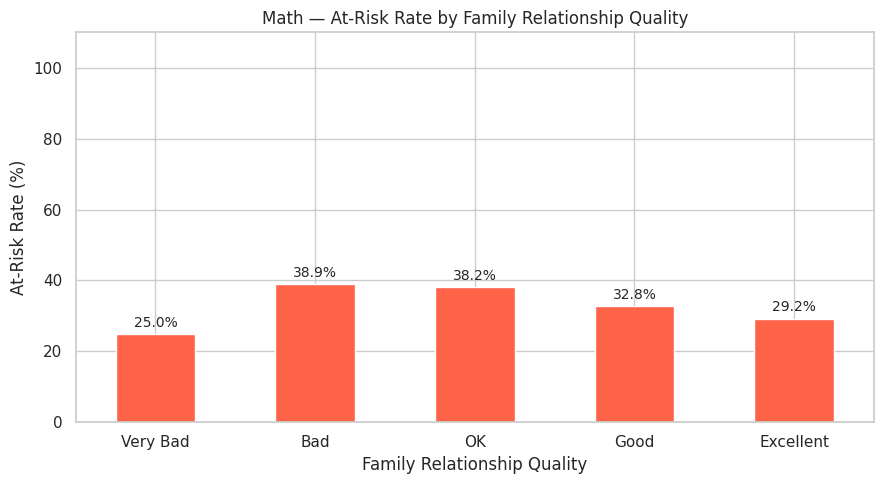

In [19]:
famrel_labels = {1:"Very Bad", 2:"Bad", 3:"OK", 4:"Good", 5:"Excellent"}

ct = pd.crosstab(mat["famrel"], mat["at_risk"], normalize="index") * 100
ct.columns = ["Not At-Risk %", "At-Risk %"]
ct.index = [famrel_labels.get(i, str(i)) for i in ct.index]

fig, ax = plt.subplots(figsize=(9, 5))
ct["At-Risk %"].plot(kind="bar", ax=ax, color="tomato", edgecolor="white", rot=0)
ax.set_title("Math — At-Risk Rate by Family Relationship Quality")
ax.set_xlabel("Family Relationship Quality")
ax.set_ylabel("At-Risk Rate (%)")
ax.set_ylim(0, 110)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width()/2, p.get_height() + 2),
                ha="center", fontsize=10)
plt.tight_layout()
plt.show()

## 14. Higher Education Aspiration vs Performance

Math — Mean G3 by higher education aspiration:
higher
no      6.80
yes    10.61
At-Risk rate:
higher
no     65.0
yes    31.2

Portuguese — Mean G3 by higher education aspiration:
higher
no      8.80
yes    12.28
At-Risk rate:
higher
no     47.8
yes    11.6



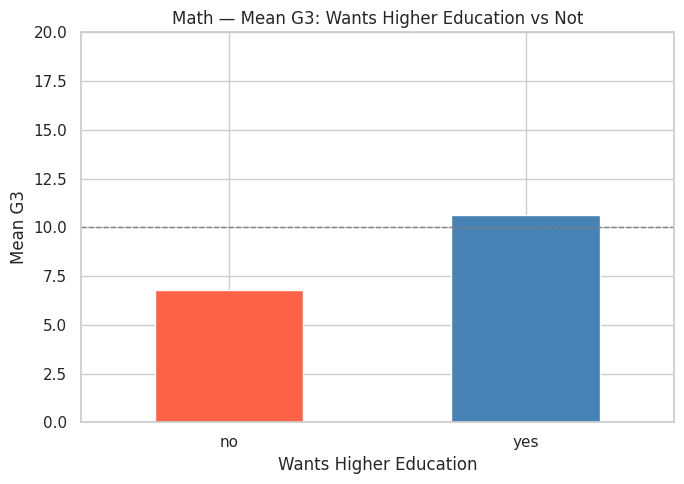

In [20]:
for df, name in [(mat, "Math"), (por, "Portuguese")]:
    grp = df.groupby("higher")["G3"].mean()
    print(f"{name} — Mean G3 by higher education aspiration:")
    print(grp.round(2).to_string())
    at_risk_rate = df.groupby("higher")["at_risk"].mean() * 100
    print("At-Risk rate:")
    print(at_risk_rate.round(1).to_string())
    print()

fig, ax = plt.subplots(figsize=(7, 5))
mat.groupby("higher")["G3"].mean().plot(kind="bar", ax=ax, color=["tomato","steelblue"],
                                         edgecolor="white", rot=0)
ax.set_title("Math — Mean G3: Wants Higher Education vs Not")
ax.set_xlabel("Wants Higher Education")
ax.set_ylabel("Mean G3")
ax.set_ylim(0, 20)
ax.axhline(y=10, color="gray", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

## 15. Internet Access & Family Support vs G3

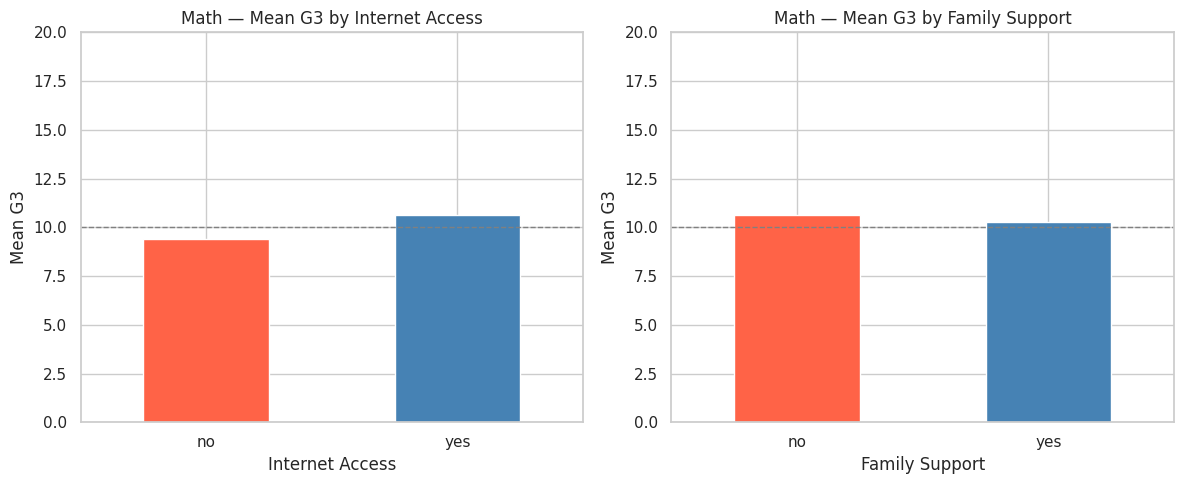

Internet access — at-risk rate:
internet
no     39.4
yes    31.6

Family support — at-risk rate:
famsup
no     29.4
yes    35.1


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, label in zip(axes, ["internet","famsup"], ["Internet Access","Family Support"]):
    mat.groupby(col)["G3"].mean().plot(kind="bar", ax=ax, color=["tomato","steelblue"],
                                        edgecolor="white", rot=0)
    ax.set_title(f"Math — Mean G3 by {label}")
    ax.set_xlabel(label)
    ax.set_ylabel("Mean G3")
    ax.set_ylim(0, 20)
    ax.axhline(y=10, color="gray", linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()

print("Internet access — at-risk rate:")
print((mat.groupby("internet")["at_risk"].mean() * 100).round(1).to_string())

print("\nFamily support — at-risk rate:")
print((mat.groupby("famsup")["at_risk"].mean() * 100).round(1).to_string())

## 16. Overlap Between Math and Portuguese Datasets

In [22]:
merge_keys = ["school","sex","age","address","famsize","Pstatus",
              "Medu","Fedu","Mjob","Fjob","reason","nursery","internet"]

overlap = pd.merge(mat, por, on=merge_keys, suffixes=("_mat","_por"))

print(f"Students in BOTH datasets : {len(overlap)}")
print(f"Students only in Math     : {len(mat) - len(overlap)}")
print(f"Students only in Portuguese: {len(por) - len(overlap)}")

if len(overlap) > 0:
    print(f"\nFor overlapping students:")
    print(f"  Mean G3 (Math)       : {overlap['G3_mat'].mean():.2f}")
    print(f"  Mean G3 (Portuguese) : {overlap['G3_por'].mean():.2f}")

Students in BOTH datasets : 382
Students only in Math     : 13
Students only in Portuguese: 267

For overlapping students:
  Mean G3 (Math)       : 10.39
  Mean G3 (Portuguese) : 12.52


## 17. Key EDA Takeaways

| # | Finding |
|---|---------|
| 1 | **G1 and G2 are the strongest predictors** of final grade — early grades are the best early warning |
| 2 | **Past failures** dramatically raise at-risk rate — even 1 failure pushes risk above 80% in Math |
| 3 | **Study time** is inversely related to at-risk — students studying <2 hrs/week are most at risk |
| 4 | **Workday alcohol (Dalc)** shows a clear upward trend in at-risk rate as consumption rises |
| 5 | **No missing values** — dataset is clean, no imputation needed |
| 6 | **Class imbalance** exists — ~69% at-risk in Math, ~55% in Portuguese — need SMOTE in training |
| 7 | **Higher education aspiration** correlates with better performance |
| 8 | **G3=0** students (~6%) are likely dropouts and are a genuine at-risk subgroup |
| 9 | **Family relations** and **parent education** show moderate influence |
| 10 | About **382 students** appear in both datasets — treat them as separate rows per subject |
